# Full Pass Detection Pipeline


# Imports

In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [6]:
from pathlib import Path

import warnings
import importlib
import joblib
import numpy as np
import pandas as pd

import src.constants as constants
import src.data_processing.dataframe as dataframe
import src.data_processing.preprocessing as preprocessing
import src.features.events as events
import src.features.features as features
import src.pipeline.dataset as dataset
import src.pipeline.pipeline as pipeline
import src.pipeline.visualization as visualization
import src.model.models as models
import src.model.io as models_io
import src.utils as utils

In [7]:
# Functions need to be reloaded after editing in .py files
importlib.reload(constants)
importlib.reload(dataframe)
importlib.reload(preprocessing)
importlib.reload(events)
importlib.reload(features)
importlib.reload(dataset)
importlib.reload(pipeline)
importlib.reload(visualization)
importlib.reload(models)
importlib.reload(models_io)
importlib.reload(utils)

<module 'src.utils' from 'c:\\Users\\samif\\Forward Football\\ML\\src\\utils.py'>

In [8]:
warnings.filterwarnings("ignore", message="Workbook contains no default style")

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load & Process Data
``pipeline()`` handles data loading, preprocessing, feature extraction, instances and features (X) and respective labels (y)

In [10]:
from src.pipeline.pipeline import pipeline

save_path = Path("../data_matches/processed/all_matches.joblib")

save_path.parent.mkdir(parents=True, exist_ok=True)

if save_path.exists():
    print("Loading preprocessed matches...")
    all_matches = joblib.load(save_path)
else:
    print("Preprocessing matches...")
    all_matches = pipeline()
    joblib.dump(all_matches, save_path)
    

Loading preprocessed matches...


# Feature Selection

In [11]:
all_matches[0]["X"].columns

Index(['x_center', 'y_center', 'ball_displacement_start_end',
       'ball_displacement_from_pitch_origin', 'displacement_std',
       'displacement_var', 'speed_max', 'speed_mean', 'speed_std',
       'ball_speed_center', 'ball_speed_start', 'ball_speed_end',
       'speed_end_minus_start', 'acc_max', 'acc_min', 'acc_abs_max',
       'acc_abs_mean', 'speed_prev_mean', 'speed_prev_std', 'direction_max',
       'direction_min', 'direction_mean', 'direction_std', 'dist_max',
       'dist_min', 'dist_mean', 'dist_center', 'dist_start', 'dist_end',
       'dist_end_minus_start', 'dist_close_start', 'dist_close_end',
       'same_closest_player_all_window', 'closest_player_changes',
       'closest_player_start_end_valid', 'closest_player_start_end_changed',
       'closest_team_share_max', 'closest_team_changes',
       'closest_team_start_end_valid', 'closest_team_start_end_changed',
       'ball_player_close_share', 'ball_player_close_any', 'streak_max',
       'streak_min', 'streak_mean

In [12]:
# Removed features based on negative feature importance using validation data

neg_cols = [
    "ball_movement_directness",
    "ball_curve_ratio",
    "speed_max_per_path_length",
    "acc_max",
    "acc_min",
    "acc_abs_max",
    "acc_abs_mean",    
    "closest_player_start_end_valid",
    "closest_team_start_end_valid",
    "streak_center",
    "streak_std",
    "closest_team_share_max",
    "own_opposition_ratio_near_center",
    "dist_player_change_std",
    "dist_player_change_max",
    "displacement_std",
    "displacement_var",
    "own_players_near_mean",
    "oppo_players_near_mean",
    "speed_std",
    "direction_std",
    "nearest_dist_opening",
    "nearest_dist_closing",
    "nearest_dist_pass_arc",
    "dist_player_change_min",
    "streak_end",
    "ball_speed_center",
]

for match in all_matches:
    match["X"] = match["X"].drop(columns=neg_cols, errors="ignore")

In [13]:
features = all_matches[0]["X"].columns

features

Index(['x_center', 'y_center', 'ball_displacement_start_end',
       'ball_displacement_from_pitch_origin', 'speed_max', 'speed_mean',
       'ball_speed_start', 'ball_speed_end', 'speed_end_minus_start',
       'speed_prev_mean', 'speed_prev_std', 'direction_max', 'direction_min',
       'direction_mean', 'dist_max', 'dist_min', 'dist_mean', 'dist_center',
       'dist_start', 'dist_end', 'dist_end_minus_start', 'dist_close_start',
       'dist_close_end', 'same_closest_player_all_window',
       'closest_player_changes', 'closest_player_start_end_changed',
       'closest_team_changes', 'closest_team_start_end_changed',
       'ball_player_close_share', 'ball_player_close_any', 'streak_max',
       'streak_min', 'streak_mean', 'streak_start', 'streak_end_minus_start',
       'own_players_near_max', 'own_players_near_min', 'oppo_players_near_max',
       'oppo_players_near_min', 'dist_player_change_mean', 'ball_path_length',
       'ball_straight_distance', 'ball_curve_distance',
    

# Split data into Train/Val/Test/

In [14]:
from sklearn.model_selection import train_test_split
from src.constants import RANDOM_STATE 

train_matches, temp_matches = train_test_split(all_matches, test_size=0.2, random_state=RANDOM_STATE)

val_matches, test_matches = train_test_split(temp_matches, test_size=0.5, random_state=RANDOM_STATE)

In [15]:
len(all_matches)

51

In [16]:
print("TRAIN: ", len(train_matches))
print("VAL: ", len(val_matches))
print("TEST: ", len(test_matches))

TRAIN:  40
VAL:  5
TEST:  6


# MASK and create groups for RandomSearchCV

In [17]:
from src.pipeline.dataset import check_stats

p_zero_before, p_one_before = check_stats(all_matches)


DATA STATS
Rows: 74191
Total NaNs: 164420
NaNs per row (avg): 2.2162

Class distribution:
0    45067
1    29124
Name: count, dtype: int64

No-pass windows:   45067
Pass windows:      29124
Pass percentage:   39.26%
No-pass percentage:60.74%


In [18]:
from src.pipeline.dataset import apply_nan_mask_with_meta

# TRAIN
for m in train_matches:
    m["X"], m["y"], m["meta"] = apply_nan_mask_with_meta(
        m["X"], 
        m["y"], 
        m["meta"]
    )

X_train = np.concatenate([m["X"] for m in train_matches])
y_train = np.concatenate([m["y"] for m in train_matches])
meta_train = pd.concat([m["meta"] for m in train_matches], ignore_index=True)

# Groups for RandomSearchCV - 1 full match is a Cross Validation
groups = np.concatenate([np.full(len(m["y"]), i) for i, m in enumerate(train_matches)])

# VALIDATION
for m in val_matches:
    m["X"], m["y"], m["meta"] = apply_nan_mask_with_meta(
        m["X"], 
        m["y"], 
        m["meta"]
    )

X_val = np.concatenate([m["X"] for m in val_matches])
y_val = np.concatenate([m["y"] for m in val_matches])
meta_val = pd.concat([m["meta"] for m in val_matches], ignore_index=True)


# TEST
for m in test_matches:
    m["X"], m["y"], m["meta"] = apply_nan_mask_with_meta(
        m["X"], 
        m["y"], 
        m["meta"]
    )

X_test = np.concatenate([m["X"] for m in test_matches])
y_test = np.concatenate([m["y"] for m in test_matches])
meta_test = pd.concat([m["meta"] for m in test_matches], ignore_index=True)

# Data Check & Visualization

In [19]:
p_zero_after, p_one_after = check_stats(all_matches)


DATA STATS
Rows: 70448
Total NaNs: 34379
NaNs per row (avg): 0.4880

Class distribution:
0    41362
1    29086
Name: count, dtype: int64

No-pass windows:   41362
Pass windows:      29086
Pass percentage:   41.29%
No-pass percentage:58.71%


In [20]:
print("0 Instances removed: ", p_zero_before - p_zero_after)
print(f"Pct: {(p_zero_before - p_zero_after) / p_zero_before * 100:.2f}%")

print("1 Instances removed: ", p_one_before - p_one_after)
print(f"Pct: {(p_one_before - p_one_after) / p_one_before * 100:.2f}%")

0 Instances removed:  3705
Pct: 8.22%
1 Instances removed:  38
Pct: 0.13%


In [21]:
from src.pipeline.dataset import check_split_pass_counts_and_actual_passes

check_split_pass_counts_and_actual_passes(y_train, meta_train, "Train after NaN removal")
check_split_pass_counts_and_actual_passes(y_val, meta_val, "Validation after NaN removal")
check_split_pass_counts_and_actual_passes(y_test, meta_test, "Test after NaN removal")


Train after NaN removal
-----------------------
Total windows:              53888
Pass windows:               22103
No-pass windows:            31785
Pass-window percentage:     41.02%
No-pass-window percentage:  58.98%
Actual passes:              25697
Extra passes compressed:    3594
Compression percentage:     13.99%

Validation after NaN removal
----------------------------
Total windows:              7779
Pass windows:               3226
No-pass windows:            4553
Pass-window percentage:     41.47%
No-pass-window percentage:  58.53%
Actual passes:              3740
Extra passes compressed:    514
Compression percentage:     13.74%

Test after NaN removal
----------------------
Total windows:              8781
Pass windows:               3757
No-pass windows:            5024
Pass-window percentage:     42.79%
No-pass-window percentage:  57.21%
Actual passes:              4387
Extra passes compressed:    630
Compression percentage:     14.36%


In [22]:
meta_all = pd.concat([meta_train, meta_val, meta_test], ignore_index=True)

positive_meta = meta_all[meta_all["pass_count"] > 0]

counts = positive_meta["pass_count"].value_counts().sort_index()
percentages = positive_meta["pass_count"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "count": counts,
    "percentage": percentages.round(2)
})

print(summary)

            count  percentage
pass_count                   
1           24684       84.87
2            4079       14.02
3             311        1.07
4              11        0.04
5               1        0.00


In [23]:
positive_windows = (meta_all["pass_count"] > 0).sum()
total_passes = meta_all["pass_count"].sum()

extra_passes_compressed = total_passes - positive_windows
percentage_compressed = extra_passes_compressed / total_passes * 100

print("Positive windows:", positive_windows)
print("Total real passes inside windows:", total_passes)
print("Extra passes compressed:", extra_passes_compressed)
print(f"Percentage of passes compressed: {percentage_compressed:.2f}%")

Positive windows: 29086
Total real passes inside windows: 33824
Extra passes compressed: 4738
Percentage of passes compressed: 14.01%


In [24]:
all_pass_locations = pd.concat([
    visualization.collect_pass_locations_from_split(train_matches, "Train"),
    visualization.collect_pass_locations_from_split(val_matches, "Validation"),
    visualization.collect_pass_locations_from_split(test_matches, "Test")
], ignore_index=True)

In [25]:
filtered_train_pass_locations = visualization.collect_filtered_pass_locations_from_split(
    train_matches,
    "Train"
)

filtered_val_pass_locations = visualization.collect_filtered_pass_locations_from_split(
    val_matches,
    "Validation"
)

filtered_test_pass_locations = visualization.collect_filtered_pass_locations_from_split(
    test_matches,
    "Test"
)

filtered_pass_locations = pd.concat(
    [
        filtered_train_pass_locations,
        filtered_val_pass_locations,
        filtered_test_pass_locations
    ],
    ignore_index=True
)

In [26]:
print("Original passes:", len(all_pass_locations))
print("Nan-filtered passes:", len(filtered_pass_locations))
print("Removed passes:", len(all_pass_locations) - len(filtered_pass_locations))

Original passes: 33869
Nan-filtered passes: 33824
Removed passes: 45


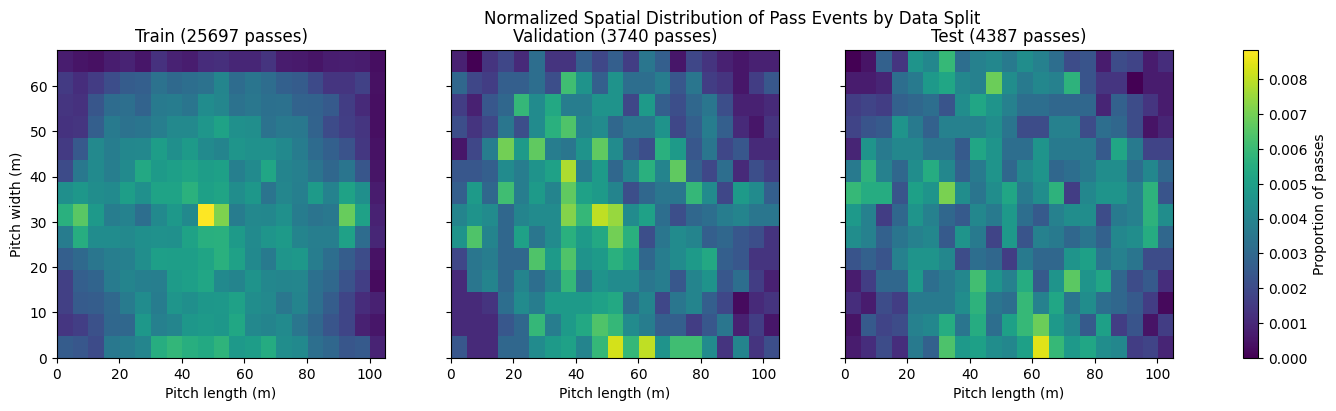

In [27]:
import matplotlib.pyplot as plt

plot_df = filtered_pass_locations.copy()

splits = [
    ("Train", plot_df[plot_df["split"] == "Train"]),
    ("Validation", plot_df[plot_df["split"] == "Validation"]),
    ("Test", plot_df[plot_df["split"] == "Test"]),
]

# Define pitch bins
x_bins = np.linspace(0, 105, 22)   # pitch length
y_bins = np.linspace(0, 68, 15)    # pitch width

heatmaps = []

for name, df in splits:
    H, _, _ = np.histogram2d(
        df["x_center"],
        df["y_center"],
        bins=[x_bins, y_bins]
    )

    # Normalize so each split sums to 1
    if H.sum() > 0:
        H = H / H.sum()

    heatmaps.append((name, df, H))

# Common color scale across all three plots
max_density = max(H.max() for _, _, H in heatmaps)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)

for ax, (name, df, H) in zip(axes, heatmaps):
    im = ax.imshow(
        H.T,
        origin="lower",
        extent=[0, 105, 0, 68],
        aspect="auto",
        vmin=0,
        vmax=max_density
    )

    ax.set_title(f"{name} ({len(df)} passes)")
    ax.set_xlim(0, 105)
    ax.set_ylim(0, 68)
    ax.set_xlabel("Pitch length (m)")
    ax.grid(False)

axes[0].set_ylabel("Pitch width (m)")



fig.colorbar(im, ax=axes, label="Proportion of passes")


plt.suptitle("Normalized Spatial Distribution of Pass Events by Data Split")
plt.show()

# Class Imbalance on Train

In [28]:
# Compute class imbalance ratio
n_neg = np.sum(y_train == 0)
n_pos = np.sum(y_train == 1)

print("Negative class:", n_neg)
print("Positive class:", n_pos)

scale = n_neg / n_pos
print("scale_pos_weight:", scale)

Negative class: 31785
Positive class: 22103
scale_pos_weight: 1.4380400850563273


# Constant Model Names

In [29]:
LR = "Logistic Regression"
SVM = "SVM"
DT = "Decision Tree"
RF = "Random Forest"
XGB = "XGBoost"
MLP = "MLP"

# Model Training

#### Logistic Regression


Running Logistic Regression with GroupKFold CV

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params for Logistic Regression: {'model__class_weight': {0: 1, 1: np.float64(1.4380400850563273)}, 'model__C': 100000, 'imputer': SimpleImputer(strategy='median')}

Best CV score: 0.7196

Best threshold: 0.400
Best F1: 0.7230
Logistic Regression - Validation results:
              precision    recall  f1-score   support

           0       0.86      0.65      0.74      4553
           1       0.63      0.85      0.72      3226

    accuracy                           0.73      7779
   macro avg       0.74      0.75      0.73      7779
weighted avg       0.76      0.73      0.73      7779



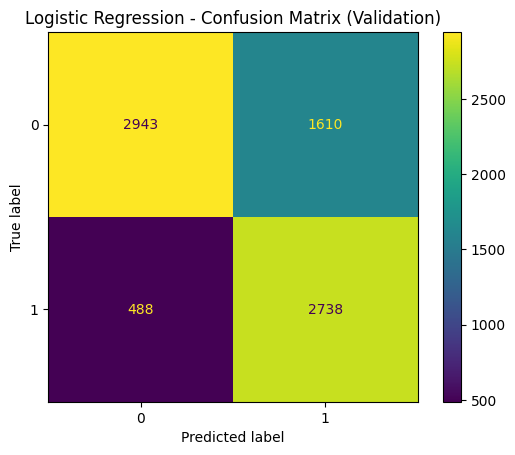

In [30]:
pipe_lr, param_dist_lr = models.build_model(LR, scale)
lr_model = models.run_random_search(pipe_lr, param_dist_lr, LR, X_train, y_train, groups)

best_model_lr = lr_model.best_estimator_
best_threshold_lr = models.find_best_threshold(best_model_lr, X_val, y_val)
models.evaluate_with_threshold(best_model_lr, LR, X_val, y_val, best_threshold_lr)

In [127]:
importance_lr = models.evaluate_feature_importance(best_model_lr, X_val, y_val, features)

player_changed_and_high_speed          0.032665
ball_displacement_from_pitch_origin    0.029974
dist_mean                              0.025513
dist_max                               0.022724
x_center                               0.020864
ball_player_close_any                  0.015593
dist_close_end                         0.010156
ball_path_length                       0.006680
closest_team_start_end_changed         0.005853
direction_min                          0.005476
streak_start                           0.005108
speed_distance_interaction             0.004834
speed_mean                             0.004075
y_center                               0.002700
streak_max                             0.002622
streak_end_minus_start                 0.002352
own_players_near_max                   0.002288
oppo_players_near_min                  0.001594
ball_curve_distance                    0.001568
speed_end_minus_start                  0.001238
streak_min                             0

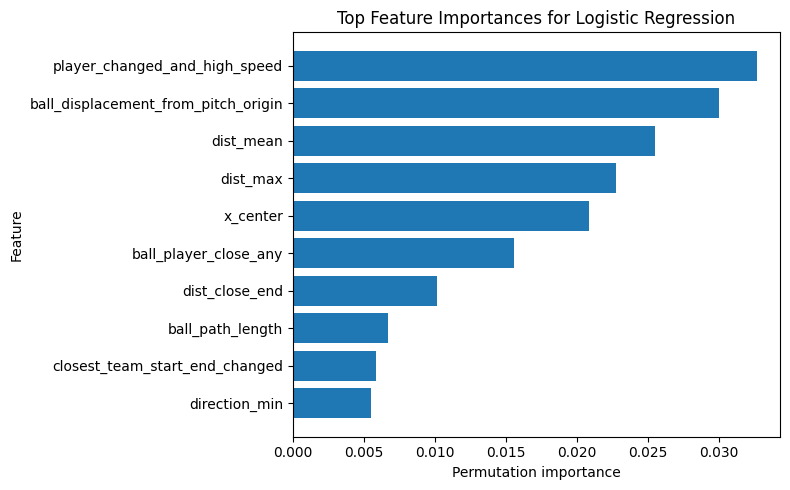

In [ ]:
visualization.plot_top_feature_importance(importance_lr, LR, top_n=10)

#### Decision Tree


Running Decision Tree with GroupKFold CV

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params for Decision Tree: {'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': 7, 'model__criterion': 'gini', 'model__class_weight': {0: 1, 1: 2}, 'imputer': SimpleImputer()}

Best CV score: 0.7203

Best threshold: 0.400
Best F1: 0.7249
Decision Tree - Validation results:
              precision    recall  f1-score   support

           0       0.87      0.64      0.73      4553
           1       0.63      0.86      0.72      3226

    accuracy                           0.73      7779
   macro avg       0.75      0.75      0.73      7779
weighted avg       0.77      0.73      0.73      7779



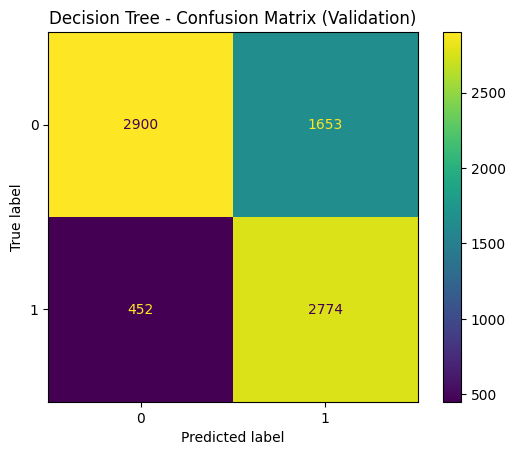

In [36]:
pipe_dt, param_dist_dt = models.build_model(DT, scale)
dt_model = models.run_random_search(pipe_dt, param_dist_dt, DT, X_train, y_train, groups)

best_model_dt = dt_model.best_estimator_
best_threshold_dt = models.find_best_threshold(best_model_dt, X_val, y_val)
models.evaluate_with_threshold(best_model_dt, DT, X_val, y_val, best_threshold_dt)

In [136]:
importance_dt = models.evaluate_feature_importance(best_model_dt, X_val, y_val, features)

player_changed_x_path_length           0.112628
ball_player_close_share                0.022115
dist_end_minus_start                   0.019664
closest_player_changes                 0.009736
ball_curve_distance                    0.009676
dist_min                               0.007769
direction_min                          0.006500
dist_end                               0.004692
speed_max                              0.004654
team_changed_x_path_length             0.004491
ball_speed_end                         0.004366
high_speed_close_to_player_share       0.004251
dist_center                            0.003479
direction_mean                         0.002914
dist_mean                              0.002845
dist_max                               0.002464
speed_prev_std                         0.001663
speed_mean                             0.001465
ball_path_length                       0.001435
y_center                               0.001410
own_players_near_max                   0

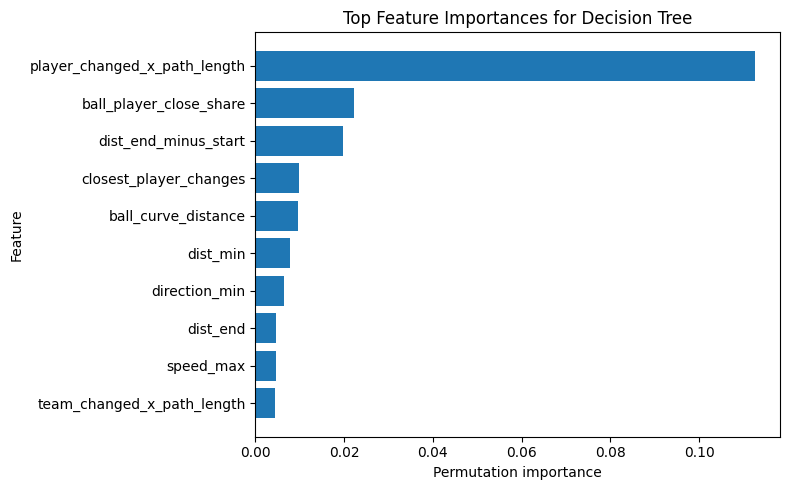

In [ ]:
visualization.plot_top_feature_importance(importance_dt, DT, top_n=10)

#### Random Forest


Running Random Forest with GroupKFold CV

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params for Random Forest: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__criterion': 'entropy', 'model__class_weight': 'balanced', 'imputer': SimpleImputer()}

Best CV score: 0.7338

Best threshold: 0.400
Best F1: 0.7386
Random Forest - Validation results:
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      4553
           1       0.65      0.85      0.74      3226

    accuracy                           0.75      7779
   macro avg       0.76      0.76      0.75      7779
weighted avg       0.78      0.75      0.75      7779



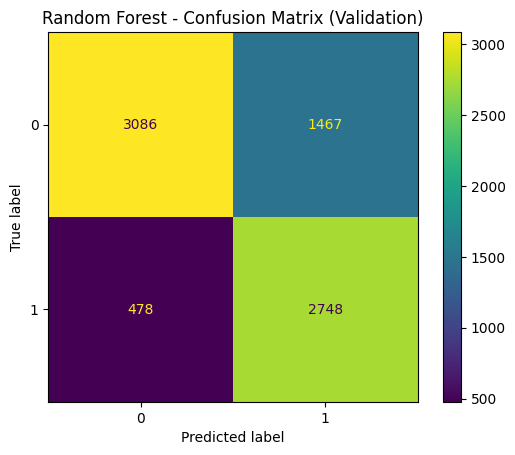

In [37]:
pipe_rf, param_dist_rf = models.build_model(RF, scale)
rf_model = models.run_random_search(pipe_rf, param_dist_rf, RF, X_train, y_train, groups)

best_model_rf = rf_model.best_estimator_
best_threshold_rf = models.find_best_threshold(best_model_rf, X_val, y_val)
models.evaluate_with_threshold(best_model_rf, RF, X_val, y_val, best_threshold_rf)

In [138]:
importance_rf = models.evaluate_feature_importance(best_model_rf, X_val, y_val, features)

dist_end_minus_start                   0.012277
dist_start                             0.006826
speed_end_minus_start                  0.006736
dist_player_change_mean                0.006509
dist_mean                              0.006063
high_speed_close_to_player_share       0.005669
speed_max                              0.005352
ball_player_close_share                0.005275
ball_path_length                       0.005219
ball_speed_end                         0.005026
player_changed_x_path_length           0.004992
player_changed_x_speed_max             0.004834
speed_mean                             0.004774
dist_end                               0.004709
direction_mean                         0.004426
ball_curve_distance                    0.004221
dist_max                               0.003612
speed_prev_mean                        0.003394
ball_straight_distance                 0.003342
direction_min                          0.003137
dist_close_start                       0

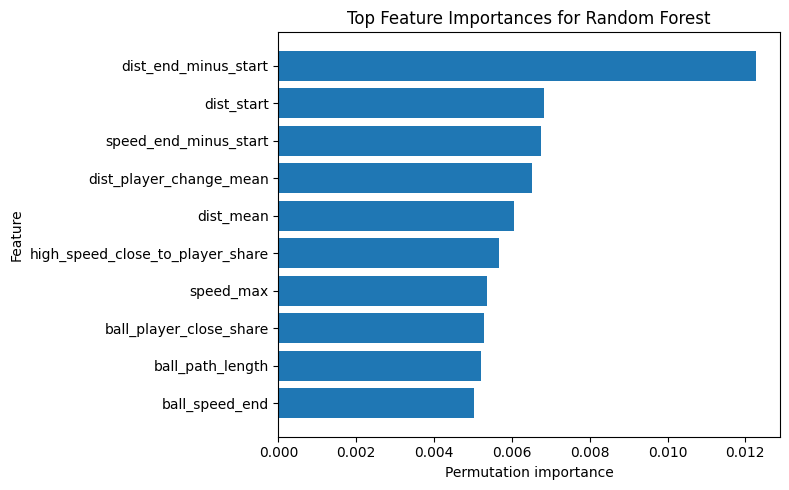

In [ ]:
visualization.plot_top_feature_importance(importance_rf, RF, top_n=10)

#### XGBoost


Running XGBoost with GroupKFold CV

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params for XGBoost: {'model__subsample': 0.8, 'model__scale_pos_weight': 2, 'model__reg_lambda': 5, 'model__reg_alpha': 0.1, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 1.0, 'imputer': SimpleImputer()}

Best CV score: 0.7384

Best threshold: 0.450
Best F1: 0.7550
XGBoost - Validation results:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4553
           1       0.67      0.87      0.76      3226

    accuracy                           0.77      7779
   macro avg       0.77      0.78      0.77      7779
weighted avg       0.79      0.77      0.77      7779



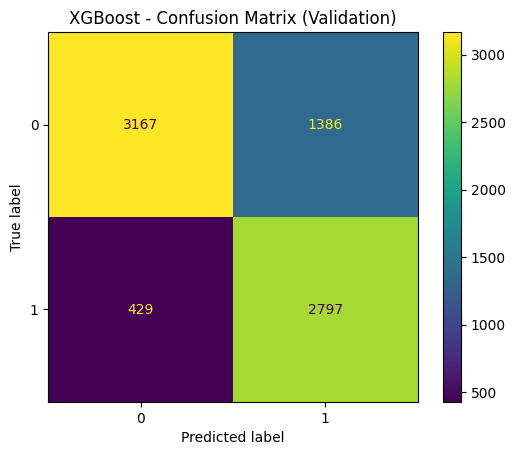

In [38]:
pipe_xgb, param_dist_xgb = models.build_model(XGB, scale)
xgb_model = models.run_random_search(pipe_xgb, param_dist_xgb, XGB, X_train, y_train, groups)

best_model_xgb = xgb_model.best_estimator_
best_threshold_xgb = models.find_best_threshold(best_model_xgb, X_val, y_val)
models.evaluate_with_threshold(best_model_xgb, XGB, X_val, y_val, best_threshold_xgb)

In [140]:
importance_xgb = models.evaluate_feature_importance(best_model_xgb, X_val, y_val, features)

player_changed_x_path_length           0.038677
dist_end                               0.011960
dist_end_minus_start                   0.009611
direction_min                          0.008934
x_center                               0.008930
ball_curve_distance                    0.008694
direction_mean                         0.008129
ball_player_close_share                0.006462
player_changed_x_speed_max             0.005871
ball_speed_end                         0.005785
dist_player_change_mean                0.005511
dist_min                               0.005493
y_center                               0.005472
speed_max                              0.005279
team_changed_x_path_length             0.004324
speed_end_minus_start                  0.004096
dist_mean                              0.004084
streak_mean                            0.003917
ball_speed_start                       0.003407
ball_displacement_from_pitch_origin    0.003394
speed_prev_mean                        0

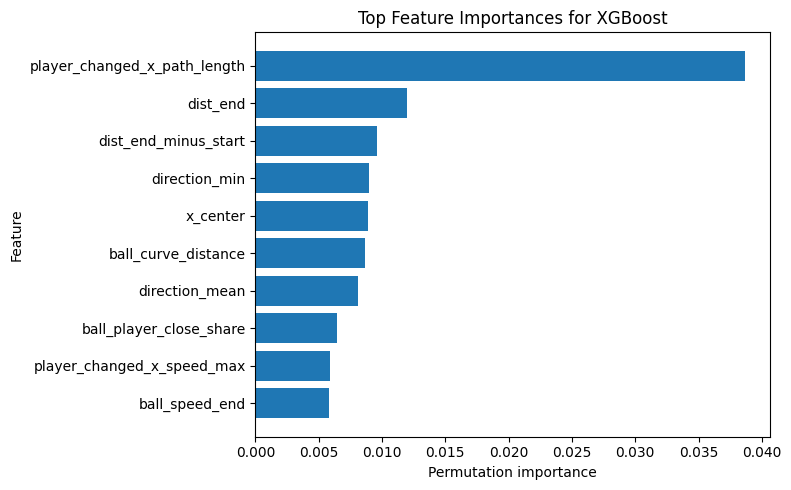

In [ ]:
visualization.plot_top_feature_importance(importance_xgb, XGB, top_n=10)

#### MLP


Running MLP with GroupKFold CV

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params for MLP: {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (64,), 'model__batch_size': 64, 'model__alpha': 0.001, 'model__activation': 'relu', 'imputer': SimpleImputer()}

Best CV score: 0.7222

Best threshold: 0.300
Best F1: 0.7433
MLP - Validation results:
              precision    recall  f1-score   support

           0       0.86      0.69      0.77      4553
           1       0.66      0.85      0.74      3226

    accuracy                           0.76      7779
   macro avg       0.76      0.77      0.76      7779
weighted avg       0.78      0.76      0.76      7779



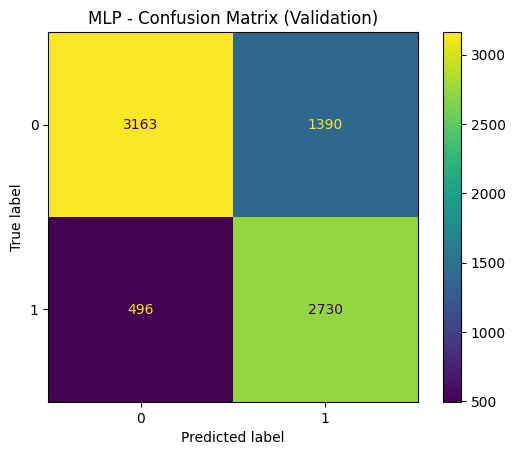

In [39]:
pipe_mlp, param_dist_mlp = models.build_model(MLP, scale)
mlp_model = models.run_random_search(pipe_mlp, param_dist_mlp, MLP, X_train, y_train, groups)

best_model_mlp = mlp_model.best_estimator_
best_threshold_mlp = models.find_best_threshold(best_model_mlp, X_val, y_val)
models.evaluate_with_threshold(best_model_mlp, MLP, X_val, y_val, best_threshold_mlp)

In [142]:
importance_mlp = models.evaluate_feature_importance(best_model_mlp, X_val, y_val, features)

ball_path_length                       0.026482
ball_displacement_from_pitch_origin    0.020221
direction_mean                         0.019257
streak_start                           0.015906
x_center                               0.013712
streak_max                             0.012697
ball_player_close_share                0.010798
high_speed_close_to_player_share       0.010481
dist_end_minus_start                   0.010447
speed_prev_mean                        0.010233
closest_player_changes                 0.010121
dist_end                               0.010023
ball_curve_distance                    0.009367
high_speed_far_from_player_share       0.009097
dist_mean                              0.008887
closest_player_start_end_changed       0.008493
ball_straight_distance                 0.007824
dist_center                            0.007593
dist_close_end                         0.007263
dist_player_change_mean                0.006925
same_closest_player_all_window         0

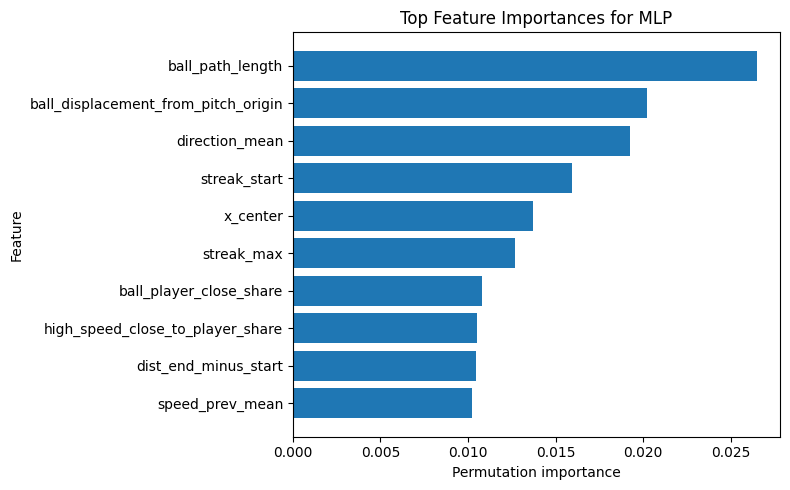

In [ ]:
visualization.plot_top_feature_importance(importance_mlp, MLP, top_n=10)

# Plot

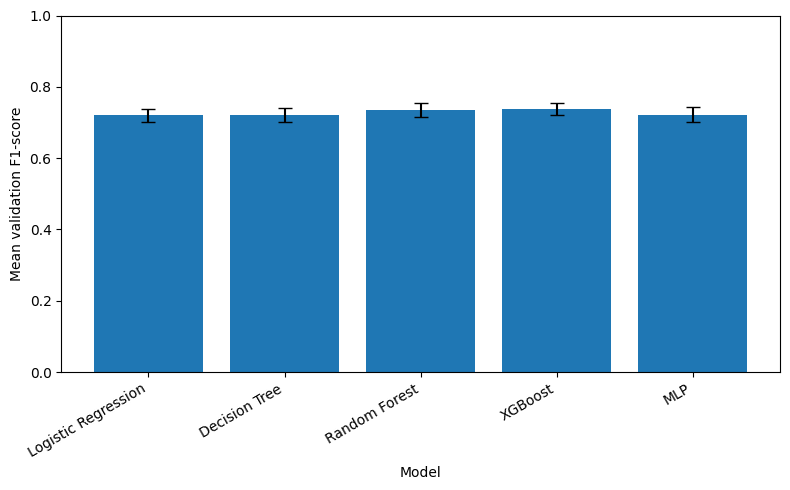

In [40]:
# convert to a function and add to visualization.py

searches = {
    LR: lr_model,
    DT: dt_model,
    RF: rf_model,
    XGB: xgb_model,
    MLP: mlp_model,
}

cv_summary = []

for model_name, search in searches.items():
    best_idx = search.best_index_

    cv_summary.append({
        "Model": model_name,
        "Mean F1": search.cv_results_["mean_test_score"][best_idx],
        "Std F1": search.cv_results_["std_test_score"][best_idx],
    })

cv_df = pd.DataFrame(cv_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    cv_df["Model"],
    cv_df["Mean F1"],
    yerr=cv_df["Std F1"],
    capsize=5
)

plt.ylabel("Mean validation F1-score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig("../plots/cv_mean_std_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# Test

In [ ]:
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

In [80]:
# Dictionary to gather results from final test
results = {}

In [83]:
features = all_matches[0]["X"].columns

features

Index(['x_center', 'y_center', 'ball_displacement_start_end',
       'ball_displacement_from_pitch_origin', 'speed_max', 'speed_mean',
       'ball_speed_start', 'ball_speed_end', 'speed_end_minus_start',
       'speed_prev_mean', 'speed_prev_std', 'direction_max', 'direction_min',
       'direction_mean', 'dist_max', 'dist_min', 'dist_mean', 'dist_center',
       'dist_start', 'dist_end', 'dist_end_minus_start', 'dist_close_start',
       'dist_close_end', 'same_closest_player_all_window',
       'closest_player_changes', 'closest_player_start_end_changed',
       'closest_team_changes', 'closest_team_start_end_changed',
       'ball_player_close_share', 'ball_player_close_any', 'streak_max',
       'streak_min', 'streak_mean', 'streak_start', 'streak_end_minus_start',
       'own_players_near_max', 'own_players_near_min', 'oppo_players_near_max',
       'oppo_players_near_min', 'dist_player_change_mean', 'ball_path_length',
       'ball_straight_distance', 'ball_curve_distance',
    

#### Logistic Regression

Model saved to: saved_models\Logistic Regression.joblib
Logistic Regression - Final results:
              precision    recall  f1-score   support

           0       0.83      0.60      0.69      5024
           1       0.61      0.84      0.70      3757

    accuracy                           0.70      8781
   macro avg       0.72      0.72      0.70      8781
weighted avg       0.74      0.70      0.70      8781



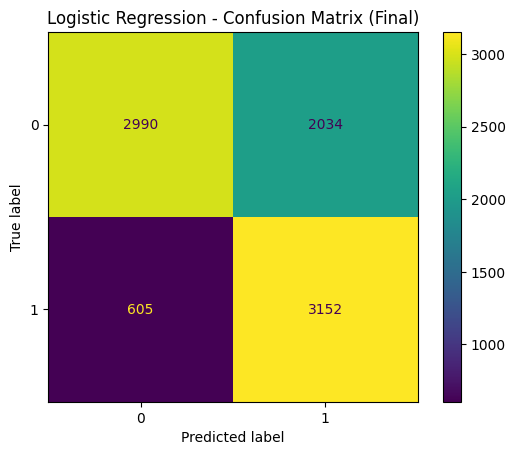

In [ ]:
logistic_regression_model = best_model_lr.fit(X_train_full, y_train_full)

models_io.save_model_package(logistic_regression_model, best_threshold_lr, LR, features)

results[LR] = models.final_evaluation(logistic_regression_model, LR, X_test, y_test, best_threshold_lr)

#### Decision Tree

Model saved to: saved_models\Decision Tree.joblib
Decision Tree - Final results:
              precision    recall  f1-score   support

           0       0.86      0.55      0.68      5024
           1       0.60      0.88      0.71      3757

    accuracy                           0.69      8781
   macro avg       0.73      0.72      0.69      8781
weighted avg       0.75      0.69      0.69      8781



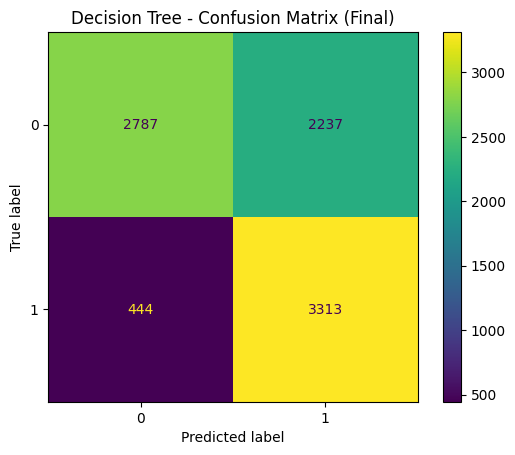

In [ ]:
decision_tree_model = best_model_dt.fit(X_train_full, y_train_full)

models_io.save_model_package(decision_tree_model, best_threshold_dt, DT, features)

results[DT] = models.final_evaluation(decision_tree_model, DT, X_test, y_test, best_threshold_dt)

#### Random Forest

Model saved to: saved_models\Random Forest.joblib
Random Forest - Final results:
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      5024
           1       0.63      0.86      0.73      3757

    accuracy                           0.73      8781
   macro avg       0.74      0.74      0.73      8781
weighted avg       0.76      0.73      0.72      8781



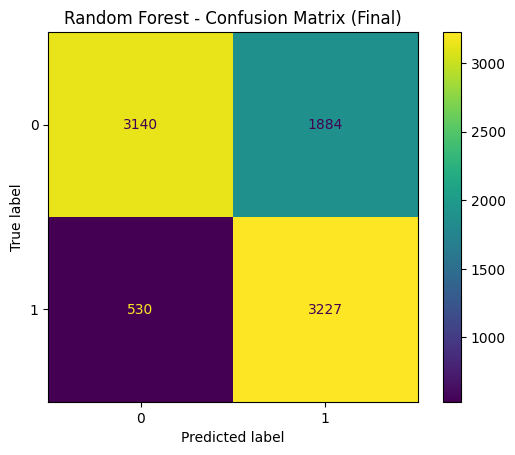

In [ ]:
random_forest_model = best_model_rf.fit(X_train_full, y_train_full)

models_io.save_model_package(random_forest_model, best_threshold_rf, RF, features)

results[RF] = models.final_evaluation(random_forest_model, RF, X_test, y_test, best_threshold_rf)

#### XGBoost

Model saved to: saved_models\XGBoost.joblib
XGBoost - Final results:
              precision    recall  f1-score   support

           0       0.87      0.64      0.74      5024
           1       0.64      0.87      0.74      3757

    accuracy                           0.74      8781
   macro avg       0.75      0.75      0.74      8781
weighted avg       0.77      0.74      0.74      8781



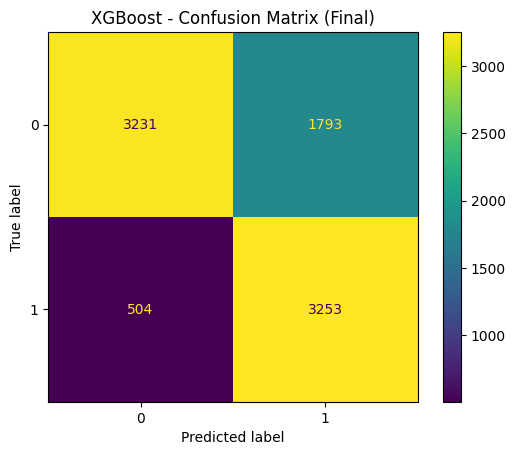

In [ ]:
xgboost_model = best_model_xgb.fit(X_train_full, y_train_full)

models_io.save_model_package(xgboost_model, best_threshold_xgb, XGB, features)

results[XGB] = models.final_evaluation(xgboost_model, XGB, X_test, y_test, best_threshold_xgb)

#### MLP

Model saved to: saved_models\MLP.joblib
MLP - Final results:
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      5024
           1       0.63      0.87      0.73      3757

    accuracy                           0.73      8781
   macro avg       0.75      0.74      0.73      8781
weighted avg       0.76      0.73      0.72      8781



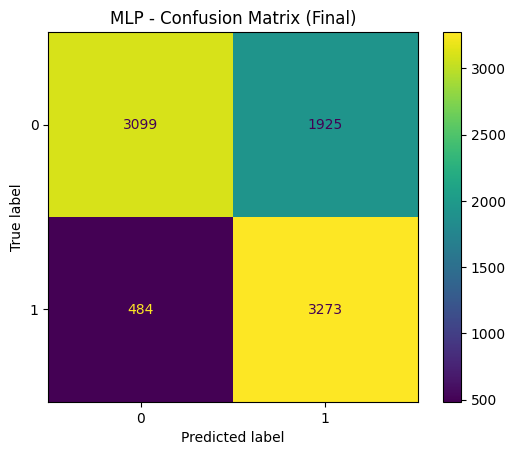

In [ ]:
mlp_model = best_model_mlp.fit(X_train_full, y_train_full)

models_io.save_model_package(mlp_model, best_threshold_mlp, MLP, features)

results[MLP] = models.final_evaluation(mlp_model, MLP, X_test, y_test, best_threshold_mlp)

# Plot F1 Val vs F1 Test

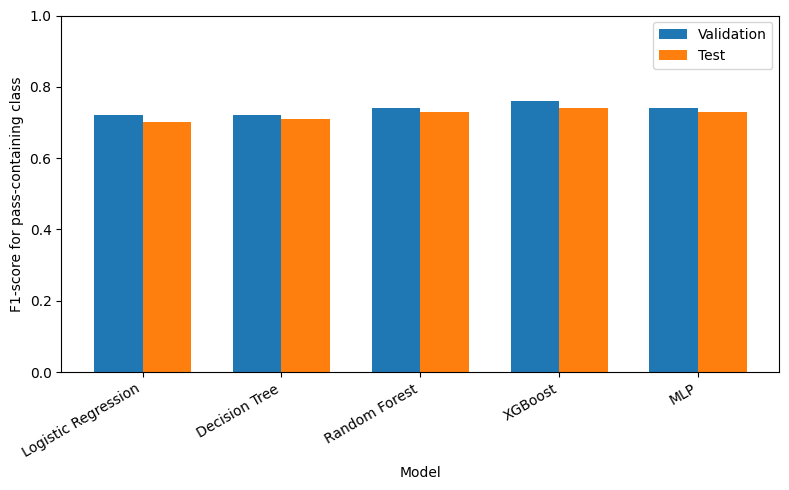

In [ ]:
# convert to a function and add to visualization.py
# Do not hard code Model, Validation F1 and Test F1 

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "MLP"
    ],
    "Validation F1": [0.72, 0.72, 0.74, 0.76, 0.74],
    "Test F1": [0.70, 0.71, 0.73, 0.74, 0.73]
})

x = np.arange(len(results["Model"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, results["Validation F1"], width, label="Validation")
plt.bar(x + width/2, results["Test F1"], width, label="Test")

plt.ylabel("F1-score for pass-containing class")
plt.xlabel("Model")
plt.xticks(x, results["Model"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig("../plots/validation_test_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()